
ALGORITMOS DE ENJAMBRE


In [ ]:
# LIBRERÍAS Y SEMILLA
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Carga y comprensión del dataset
`X` contiene las variables de entrada y `y` contiene la clase objetivo (0 = maligno, 1 = benigno). El dataset de Cáncer de Mama tiene **569 registros**, **30 características** y **2 clases**.

In [ ]:
# CARGA DEL DATASET
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target
nombres_caracteristicas = list(cancer.feature_names)

print("Dimensión de X:", X.shape)
print("Número de clases:", len(np.unique(y)))
print()
print("Primeras características del dataset:")
for i, nombre in enumerate(nombres_caracteristicas[:10], start=1):
    print(f"{i:2d}. {nombre}")
print("   ... (y 20 características más)")

# Vista tabular para entender los datos
muestra = pd.DataFrame(X, columns=nombres_caracteristicas)
muestra["clase"] = y
print("\nPrimeras filas del DataFrame:")
display(muestra.head())

Dimensión de X: (569, 30)
Número de clases: 2

Primeras características del dataset:
 1. mean radius
 2. mean texture
 3. mean perimeter
 4. mean area
 5. mean smoothness
 6. mean compactness
 7. mean concavity
 8. mean concave points
 9. mean symmetry
10. mean fractal dimension
   ... (y 20 características más)

Primeras filas del DataFrame:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,clase
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# DIVISIÓN DE DATOS
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=SEMILLA
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (426, 30)
Prueba: (143, 30)


## **Ejemplo 3: Red Neuronal sin Backpropagation (usando PSO)**



In [ ]:
# 1. ARQUITECTURA DE LA RED NEURONAL Y FORWARD PASS
# definimos directamente la estructura de la red de 3 capas:
# - Capa de Entrada: 30 características
# - Capa Oculta: 5 neuronas (con activación tanh)
# - Capa de Salida: 1 neurona (con activación sigmoide para clasificación binaria)

n_entradas = X_train.shape[1] # 30
n_ocultas = 5

# Dimensión total del vector de la partícula (todos los pesos y sesgos aplanados):
# (30 * 5) [W1] + 5 [b1] + (5 * 1) [W2] + 1 [b2] = 150 + 5 + 5 + 1 = 161 dimensiones
n_dimensiones_nn = (n_entradas * n_ocultas) + n_ocultas + (n_ocultas * 1) + 1

def propagacion_hacia_delatante(vector_pesos, X_datos):
    """Desempaqueta el vector plano en matrices de pesos y bias, y realiza el Forward Pass."""
    w1_fin = n_entradas * n_ocultas
    b1_fin = w1_fin + n_ocultas
    w2_fin = b1_fin + n_ocultas

    W1 = vector_pesos[:w1_fin].reshape(n_entradas, n_ocultas)
    b1 = vector_pesos[w1_fin:b1_fin]
    W2 = vector_pesos[b1_fin:w2_fin].reshape(n_ocultas, 1)
    b2 = vector_pesos[w2_fin:]

    # Capa oculta con activación tanh
    salida_oculta = np.tanh(np.dot(X_datos, W1) + b1)
    # Capa de salida con función sigmoide (valores entre 0 y 1)
    salida_final = 1 / (1 + np.exp(-np.dot(salida_oculta, W2) - b2))

    return salida_final.flatten()

print(f"Dimensiones de los parámetros de la Red Neuronal por partícula: {n_dimensiones_nn}")

Dimensiones de los parámetros de la Red Neuronal por partícula: 161


## 1. Función de Aptitud (Fitness - Minimización del Error MSE)
Dado que el objetivo es minimizar el error de predicción de la red, la función de aptitud calcula el **Error Cuadrático Medio (MSE)** entre las salidas predichas por la red y las etiquetas reales (`y_train`).

In [ ]:
# 2. FUNCIÓN FITNESS (Error Cuadrático Medio - MSE)
def calcular_fitness_nn(vector_pesos):
    predicciones = propagacion_hacia_delatante(vector_pesos, X_train)
    mse = np.mean((predicciones - y_train) ** 2)
    return mse # Queremos minimizar este error

print("Función fitness de la red neuronal definida correctamente.")

Función fitness de la red neuronal definida correctamente.


## 2. Inicialización del enjambre y algoritmo PSO para la Red Neuronal
Cada partícula del enjambre representa una red neuronal completa con valores de pesos y sesgos inicializados aleatoriamente entre -1 y 1. El PSO ajusta iterativamente estos valores guiándose hacia la partícula con menor error (`gbest`), sin requerir derivadas ni retropropagación.

In [ ]:
# 3. ALGORITMO PSO PARA ENTRENAR LA RED NEURONAL
def entrenar_nn_con_pso(
    n_particulas=15,
    max_iteraciones=20,
    w=0.5,
    c1=1.5,
    c2=1.5
):
    np.random.seed(SEMILLA)

    # Inicializar posiciones y velocidades aleatorias para los pesos de la red
    posiciones = np.random.uniform(-1.0, 1.0, size=(n_particulas, n_dimensiones_nn))
    velocidades = np.random.uniform(-0.1, 0.1, size=(n_particulas, n_dimensiones_nn))

    p_best_posiciones = posiciones.copy()
    p_best_errores = np.array([calcular_fitness_nn(p) for p in posiciones])

    indice_mejor = np.argmin(p_best_errores)
    g_best_posicion = posiciones[indice_mejor].copy()
    g_best_error = p_best_errores[indice_mejor]

    historial = []

    print("INICIO DEL ENTRENAMIENTO DE LA RED NEURONAL CON PSO (SIN BACKPROPAGATION)")
    print("=" * 78)

    for iteracion in range(1, max_iteraciones + 1):
        for i in range(n_particulas):
            error_actual = calcular_fitness_nn(posiciones[i])

            # Actualizar mejor personal (pbest) - en minimización buscamos menor error
            if error_actual < p_best_errores[i]:
                p_best_errores[i] = error_actual
                p_best_posiciones[i] = posiciones[i].copy()

            # Actualizar mejor global (gbest)
            if error_actual < g_best_error:
                g_best_error = error_actual
                g_best_posicion = posiciones[i].copy()

        # Comportamiento: Actualización de velocidad y posición de las partículas
        for i in range(n_particulas):
            r1, r2 = random.random(), random.random()

            # La Ecuación de Velocidad del PSO

            velocidades[i] = (
                w * velocidades[i] +
                c1 * r1 * (p_best_posiciones[i] - posiciones[i]) +
                c2 * r2 * (g_best_posicion - posiciones[i])
            )
            posiciones[i] += velocidades[i]

        historial.append({
            "iteracion": iteracion,
            "mejor_error_mse": g_best_error,
            "error_promedio": float(np.mean(p_best_errores))
        })

        print(
            f"Iteración {iteracion:02d} | "
            f"Mejor Error MSE (gbest): {g_best_error:.5f} | "
            f"Error promedio enjambre: {np.mean(p_best_errores):.5f}"
        )

    return g_best_posicion, g_best_error, pd.DataFrame(historial)

mejor_pesos_nn, mejor_error_nn, historial_nn = entrenar_nn_con_pso()

INICIO DEL ENTRENAMIENTO DE LA RED NEURONAL CON PSO (SIN BACKPROPAGATION)
Iteración 01 | Mejor Error MSE (gbest): 0.25065 | Error promedio enjambre: 0.37378
Iteración 02 | Mejor Error MSE (gbest): 0.23988 | Error promedio enjambre: 0.28700
Iteración 03 | Mejor Error MSE (gbest): 0.20131 | Error promedio enjambre: 0.25686
Iteración 04 | Mejor Error MSE (gbest): 0.20131 | Error promedio enjambre: 0.23031
Iteración 05 | Mejor Error MSE (gbest): 0.20131 | Error promedio enjambre: 0.22936
Iteración 06 | Mejor Error MSE (gbest): 0.20131 | Error promedio enjambre: 0.22828
Iteración 07 | Mejor Error MSE (gbest): 0.19087 | Error promedio enjambre: 0.22240
Iteración 08 | Mejor Error MSE (gbest): 0.19087 | Error promedio enjambre: 0.21835
Iteración 09 | Mejor Error MSE (gbest): 0.19087 | Error promedio enjambre: 0.21697
Iteración 10 | Mejor Error MSE (gbest): 0.17194 | Error promedio enjambre: 0.20875
Iteración 11 | Mejor Error MSE (gbest): 0.16259 | Error promedio enjambre: 0.20564
Iteración 12 

## 3. Evaluación final de la Red Neuronal entrenada por PSO
Se evalúa el rendimiento de la red neuronal en el conjunto de prueba (`X_test`), convirtiendo las salidas continuas de la sigmoide en clases binarias (0 o 1) mediante un umbral de 0.5 para calcular su precisión (*accuracy*).

In [ ]:
# 4. RESULTADOS Y EVALUACIÓN FINAL EN TEST
preds_test = propagacion_hacia_delatante(mejor_pesos_nn, X_test)
preds_test_binarias = (preds_test >= 0.5).astype(int)
acc_test_nn = accuracy_score(y_test, preds_test_binarias)

print("\n" + "=" * 78)
print("RESULTADOS FINALES - RED NEURONAL ENTRENADA CON PSO (SIN BACKPROPAGATION)")
print("=" * 78)
print(f"Error MSE mínimo alcanzado en entrenamiento: {mejor_error_nn:.5f}")
print(f"Accuracy de la Red Neuronal en Prueba (Test): {acc_test_nn * 100:.2f}%")


RESULTADOS FINALES - RED NEURONAL ENTRENADA CON PSO (SIN BACKPROPAGATION)
Error MSE mínimo alcanzado en entrenamiento: 0.13719
Accuracy de la Red Neuronal en Prueba (Test): 83.92%


## 4. Curva de evolución del entrenamiento
La gráfica muestra la disminución del Error Cuadrático Medio (MSE) del enjambre a lo largo de las iteraciones durante el entrenamiento de la red neuronal sin usar gradientes.

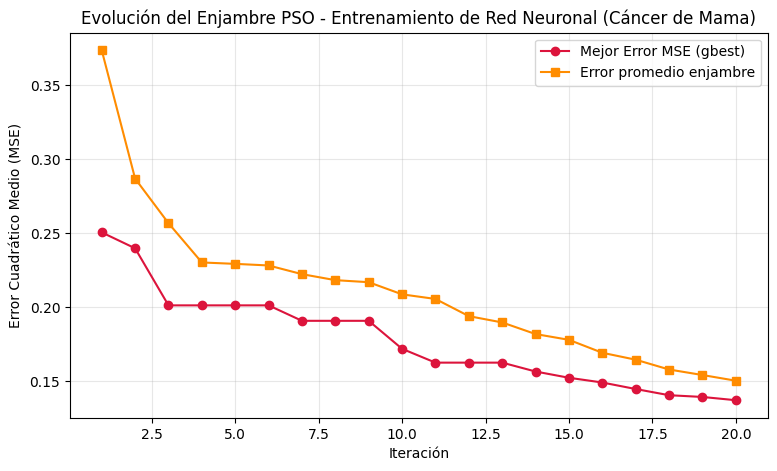

In [ ]:
# 5. GRÁFICA DE EVOLUCIÓN (ENTRENAMIENTO NN)
plt.figure(figsize=(9, 5))
plt.plot(historial_nn["iteracion"], historial_nn["mejor_error_mse"], marker="o", label="Mejor Error MSE (gbest)", color="crimson")
plt.plot(historial_nn["iteracion"], historial_nn["error_promedio"], marker="s", label="Error promedio enjambre", color="darkorange")
plt.xlabel("Iteración")
plt.ylabel("Error Cuadrático Medio (MSE)")
plt.title("Evolución del Enjambre PSO - Entrenamiento de Red Neuronal (Cáncer de Mama)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# **Ejemplo 4: Clustering (Agrupamiento) con PSO**


In [ ]:
# CREAR X_SCALED PARA EL CLUSTERING (EXACTAMENTE AQUÍ)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Datos normalizados para clustering correctamente. Shape:", X_scaled.shape)

Datos normalizados para clustering correctamente. Shape: (569, 30)


In [ ]:
# Definimos K = 2 grupos (maligno y benigno)
K = 2
n_caracteristicas = X_scaled.shape[1] # 30 dimensiones

# Dimensión de la partícula: K centroides * 30 características = 60 valores aplanados
n_dimensiones_cluster = K * n_caracteristicas

def calcular_fitness_clustering(vector_posicion):
    """Calcula la inercia (SSE) de los centroides representados por la partícula."""
    # Reestructurar el vector plano a matriz de centroides de forma (K, n_caracteristicas)
    centroides = vector_posicion.reshape(K, n_caracteristicas)

    # Calcular distancia euclidiana de cada muestra a cada centroide
    distancias = np.linalg.norm(X_scaled[:, np.newaxis, :] - centroides, axis=2)

    # Asignar cada muestra al centroide más cercano
    asignaciones = np.argmin(distancias, axis=1)

    # Calcular la suma de errores cuadráticos (SSE)
    sse = 0.0
    for k in range(K):
        puntos_cluster = X_scaled[asignaciones == k]
        if len(puntos_cluster) > 0:
            sse += np.sum((puntos_cluster - centroides[k]) ** 2)

    return sse # Queremos minimizar el SSE

print("Función fitness de clustering (SSE) configurada correctamente.")

Función fitness de clustering (SSE) configurada correctamente.


## 1. Inicialización y Algoritmo PSO para Clustering
Se inicializan las partículas seleccionando aleatoriamente subconjuntos de muestras del dataset como centroides iniciales. El enjambre actualiza iterativamente sus velocidades y posiciones para minimizar el SSE.

In [ ]:
# ALGORITMO PSO PARA CLUSTERING
def optimizar_clustering_pso(
    n_particulas=12,
    max_iteraciones=20,
    w=0.5,
    c1=1.5,
    c2=1.5
):
    np.random.seed(SEMILLA)
    random.seed(SEMILLA)

    # Inicializar posiciones tomando muestras aleatorias del dataset normalizado
    posiciones = np.array([
        X_scaled[np.random.choice(X_scaled.shape[0], K, replace=False)].flatten()
        for _ in range(n_particulas)
    ])
    velocidades = np.random.uniform(-0.1, 0.1, size=(n_particulas, n_dimensiones_cluster))

    p_best_posiciones = posiciones.copy()
    p_best_scores = np.array([calcular_fitness_clustering(p) for p in posiciones])

    indice_mejor = np.argmin(p_best_scores) # En minimización, buscamos el menor SSE
    g_best_posicion = posiciones[indice_mejor].copy()
    g_best_score = p_best_scores[indice_mejor]

    historial = []

    print("INICIO DEL ALGORITMO PSO - CLUSTERING")
    print("=" * 78)

    for iteracion in range(1, max_iteraciones + 1):
        for i in range(n_particulas):
            score_actual = calcular_fitness_clustering(posiciones[i])

            # Actualizar mejor personal (pbest)
            if score_actual < p_best_scores[i]:
                p_best_scores[i] = score_actual
                p_best_posiciones[i] = posiciones[i].copy()

            # Actualizar mejor global (gbest)
            if score_actual < g_best_score:
                g_best_score = score_actual
                g_best_posicion = posiciones[i].copy()

        # Comportamiento: Actualización de velocidad y posición
        for i in range(n_particulas):
            r1, r2 = random.random(), random.random()
            velocidades[i] = (
                w * velocidades[i] +
                c1 * r1 * (p_best_posiciones[i] - posiciones[i]) +
                c2 * r2 * (g_best_posicion - posiciones[i])
            )
            posiciones[i] += velocidades[i]

        historial.append({
            "iteracion": iteracion,
            "mejor_sse": g_best_score,
            "sse_promedio": float(np.mean(p_best_scores))
        })

        print(
            f"Iteración {iteracion:02d} | "
            f"Mejor SSE (gbest): {g_best_score:.2f} | "
            f"SSE Promedio enjambre: {np.mean(p_best_scores):.2f}"
        )

    return g_best_posicion, g_best_score, pd.DataFrame(historial)

mejor_centroides_pso, mejor_sse_pso, historial_cluster = optimizar_clustering_pso()

INICIO DEL ALGORITMO PSO - CLUSTERING
Iteración 01 | Mejor SSE (gbest): 14858.87 | SSE Promedio enjambre: 21464.87
Iteración 02 | Mejor SSE (gbest): 14466.47 | SSE Promedio enjambre: 18303.83
Iteración 03 | Mejor SSE (gbest): 14466.47 | SSE Promedio enjambre: 15700.82
Iteración 04 | Mejor SSE (gbest): 14347.34 | SSE Promedio enjambre: 15154.51
Iteración 05 | Mejor SSE (gbest): 14146.08 | SSE Promedio enjambre: 14857.35
Iteración 06 | Mejor SSE (gbest): 14106.12 | SSE Promedio enjambre: 14690.75
Iteración 07 | Mejor SSE (gbest): 14106.12 | SSE Promedio enjambre: 14562.35
Iteración 08 | Mejor SSE (gbest): 14106.12 | SSE Promedio enjambre: 14287.08
Iteración 09 | Mejor SSE (gbest): 14048.40 | SSE Promedio enjambre: 14225.05
Iteración 10 | Mejor SSE (gbest): 13861.74 | SSE Promedio enjambre: 14184.73
Iteración 11 | Mejor SSE (gbest): 13861.74 | SSE Promedio enjambre: 14095.47
Iteración 12 | Mejor SSE (gbest): 13861.74 | SSE Promedio enjambre: 14032.51
Iteración 13 | Mejor SSE (gbest): 1380

## 2. Evaluación final y visualización del agrupamiento
Se obtienen los centroides definitivos descubiertos por el enjambre, se asignan las muestras y se grafica el resultado en un plano bidimensional empleando las dos primeras variables principales de los datos.


RESULTADOS FINALES - CLUSTERING CON PSO
SSE (Inercia) mínimo alcanzado: 13681.78
Muestras asignadas al Grupo 0: 403
Muestras asignadas al Grupo 1: 166


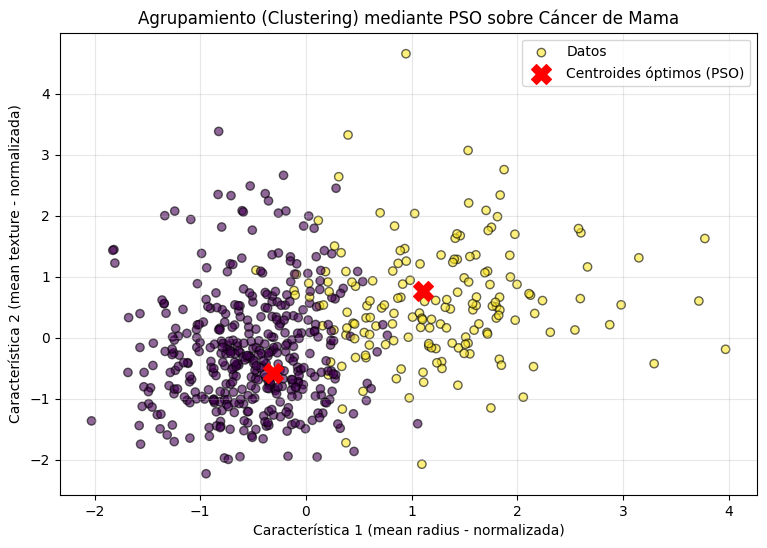

In [ ]:
# EVALUACIÓN Y VISUALIZACIÓN DE CLUSTERS
centroides_finales = mejor_centroides_pso.reshape(K, n_caracteristicas)
distancias_finales = np.linalg.norm(X_scaled[:, np.newaxis, :] - centroides_finales, axis=2)
clusters_predichos = np.argmin(distancias_finales, axis=1)

print("\n" + "=" * 78)
print("RESULTADOS FINALES - CLUSTERING CON PSO")
print("=" * 78)
print(f"SSE (Inercia) mínimo alcanzado: {mejor_sse_pso:.2f}")
print(f"Muestras asignadas al Grupo 0: {np.sum(clusters_predichos == 0)}")
print(f"Muestras asignadas al Grupo 1: {np.sum(clusters_predichos == 1)}")

# Gráfica de dispersión de los grupos hallados por PSO
plt.figure(figsize=(9, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_predichos, cmap='viridis', alpha=0.6, edgecolors='k', label='Datos')
plt.scatter(centroides_finales[:, 0], centroides_finales[:, 1], c='red', marker='X', s=200, label='Centroides óptimos (PSO)')
plt.xlabel("Característica 1 (mean radius - normalizada)")
plt.ylabel("Característica 2 (mean texture - normalizada)")
plt.title("Agrupamiento (Clustering) mediante PSO sobre Cáncer de Mama")
plt.legend()
plt.grid(alpha=0.3)
plt.show()